# 🩵 Étape 1 — Nettoyage du dataset *Life Expectancy (WHO)*

## 🎯 Objectif
Rendre les données brutes exploitables :
- Identifier et gérer les valeurs manquantes  
- Corriger les types de variables  
- Détecter les doublons et les valeurs aberrantes  
- Préparer un dataset propre pour l’analyse exploratoire  

---



In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# ➜ mets ici ton chemin ABSOLU (celui qui a marché)
RAW = Path(r"C:\Users\dinay\Desktop\laplateforme\B2_IA\dazzle-dash\dazzle-dash\data\raw\Life Expectancy Data.csv")

# ➜ on construit automatiquement le chemin "clean" à côté de /data/raw
CLEAN = RAW.parent.parent / "clean" / "who_life_clean.csv"
CLEAN.parent.mkdir(parents=True, exist_ok=True)

print("RAW :", RAW)
print("CLEAN :", CLEAN)


RAW : C:\Users\dinay\Desktop\laplateforme\B2_IA\dazzle-dash\dazzle-dash\data\raw\Life Expectancy Data.csv
CLEAN : C:\Users\dinay\Desktop\laplateforme\B2_IA\dazzle-dash\dazzle-dash\data\clean\who_life_clean.csv


In [4]:
# 📄 Lecture du dataset brut + affichage des 5 premières lignes
df = pd.read_csv(RAW, sep=None, engine="python")
df.columns = df.columns.str.strip()  # enlève les espaces dans les noms de colonnes

print("Dimensions du dataset :", df.shape)
df.head()


Dimensions du dataset : (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
# 🔍 Vérifions les types et les colonnes disponibles
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
# 🔢 Statistiques descriptives rapides pour les colonnes numériques
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


In [7]:
# 🚨 Valeurs manquantes
na_counts = df.isna().sum().sort_values(ascending=False)
na_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing = pd.DataFrame({
    "Valeurs manquantes": na_counts,
    "% du total": na_percent.round(2)
})
missing.head(10)


,Valeurs manquantes,% du total
Population,652,22.19
Hepatitis B,553,18.82
GDP,448,15.25
Total expenditure,226,7.69
Alcohol,194,6.60
Income composition of resources,167,5.68
Schooling,163,5.55
thinness 1-19 years,34,1.16
thinness 5-9 years,34,1.16
BMI,34,1.16


In [9]:
# 🧽 On supprime les lignes sans valeurs essentielles
df = df.dropna(subset=["Country", "Year", "Life expectancy"])

# 🔁 Fonction pour remplir les NA par la médiane du pays (ou globale)
def impute_by_country_median(frame, col):
    if col not in frame.columns: 
        return frame
    med_global = frame[col].median()
    frame[col] = frame.groupby("Country")[col].transform(lambda s: s.fillna(s.median()))
    frame[col] = frame[col].fillna(med_global)
    return frame

# 🧮 Colonnes à imputer
cols_to_impute = [
    "GDP", "Schooling", "Income composition of resources",
    "Alcohol", "BMI", "Adult Mortality", "Population"
]
for col in cols_to_impute:
    df = impute_by_country_median(df, col)

# ✅ Vérifions s'il reste encore des valeurs manquantes
df.isna().sum().sort_values(ascending=False).head(10)


Hepatitis B             553
Total expenditure       226
thinness 5-9 years       32
thinness  1-19 years     32
Diphtheria               19
Polio                    19
infant deaths             0
Adult Mortality           0
Life expectancy           0
Status                    0
dtype: int64

In [10]:
# 🧩 Imputation simple des dernières colonnes manquantes par la médiane globale
cols_remaining = ["Hepatitis B", "Total expenditure", "thinness 5-9 years", 
                  "thinness  1-19 years", "Diphtheria", "Polio"]

for col in cols_remaining:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# ✅ Vérification finale
print("Valeurs manquantes restantes :")
print(df.isna().sum().sum())

# 🎯 On garde uniquement les années plausibles et valeurs cohérentes
df = df[(df["Year"] >= 1990) & (df["Year"] <= 2015)]
df = df[(df["Life expectancy"] > 0) & (df["Life expectancy"] < 100)]

# 🚨 Détection d’éventuelles valeurs aberrantes (hors bornes)
def flag_iqr(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < low) | (s > high)

for col in ["Life expectancy", "GDP", "Schooling", "Adult Mortality"]:
    df[f"{col}_outlier"] = flag_iqr(df[col])

print("✅ Nettoyage terminé. Dimensions finales :", df.shape)


Valeurs manquantes restantes :
0
✅ Nettoyage terminé. Dimensions finales : (2928, 26)


In [11]:
# 💾 Sauvegarde du fichier nettoyé
df.to_csv(CLEAN, index=False)
print("Fichier nettoyé sauvegardé :", CLEAN.resolve())


Fichier nettoyé sauvegardé : C:\Users\dinay\Desktop\laplateforme\B2_IA\dazzle-dash\dazzle-dash\data\clean\who_life_clean.csv


🧠statistiques globales


In [12]:
# ⚙️ Lecture du fichier propre
import pandas as pd
df = pd.read_csv(r"C:\Users\dinay\Desktop\laplateforme\B2_IA\dazzle-dash\dazzle-dash\data\clean\who_life_clean.csv")

# 📊 Statistiques générales
print("Nombre de pays :", df["Country"].nunique())
print("Période couverte :", df["Year"].min(), "→", df["Year"].max())
print("Moyenne d'espérance de vie :", round(df["Life expectancy"].mean(), 1), "ans")
print("Moyenne du PIB (GDP) :", round(df["GDP"].mean(), 2))
print("Moyenne du niveau de scolarité :", round(df["Schooling"].mean(), 1), "années")


Nombre de pays : 183
Période couverte : 2000 → 2015
Moyenne d'espérance de vie : 69.2 ans
Moyenne du PIB (GDP) : 6619.56
Moyenne du niveau de scolarité : 12.0 années


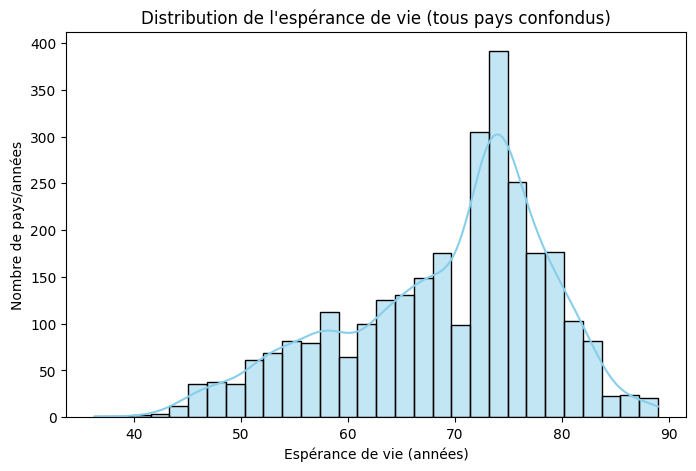

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Life expectancy"], bins=30, color="skyblue", kde=True)
plt.title("Distribution de l'espérance de vie (tous pays confondus)")
plt.xlabel("Espérance de vie (années)")
plt.ylabel("Nombre de pays/années")
plt.show()


C:\Users\dinay\AppData\Local\Temp\ipykernel_13420\1506067968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")


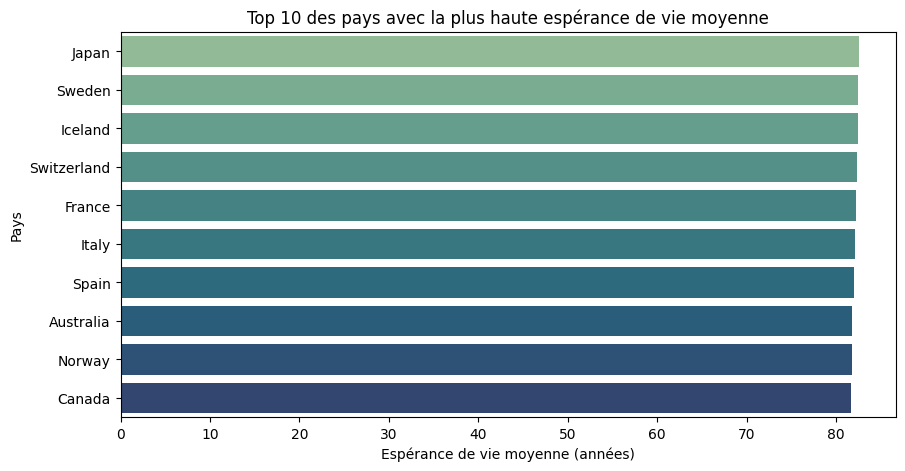

In [16]:
top_countries = df.groupby("Country")["Life expectancy"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="crest")
plt.title("Top 10 des pays avec la plus haute espérance de vie moyenne")
plt.xlabel("Espérance de vie moyenne (années)")
plt.ylabel("Pays")
plt.show()


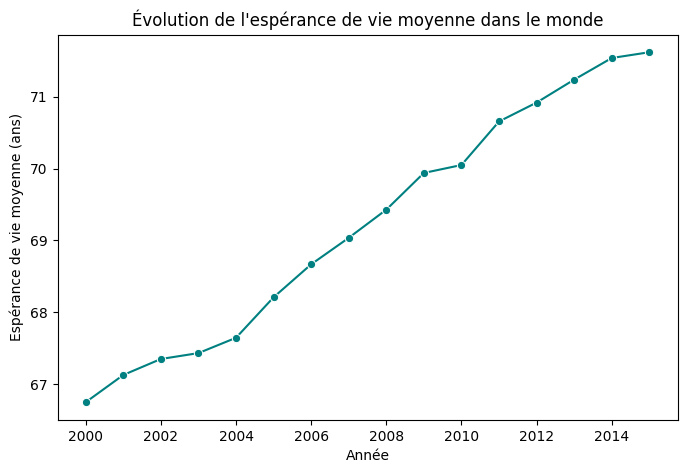

In [17]:
yearly = df.groupby("Year")["Life expectancy"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=yearly, x="Year", y="Life expectancy", marker="o", color="teal")
plt.title("Évolution de l'espérance de vie moyenne dans le monde")
plt.xlabel("Année")
plt.ylabel("Espérance de vie moyenne (ans)")
plt.show()


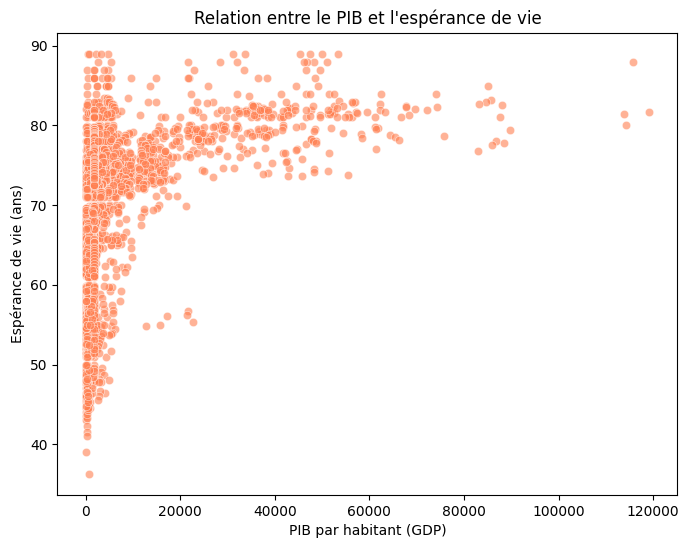

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="GDP", y="Life expectancy", alpha=0.6, color="coral")
plt.title("Relation entre le PIB et l'espérance de vie")
plt.xlabel("PIB par habitant (GDP)")
plt.ylabel("Espérance de vie (ans)")
plt.show()


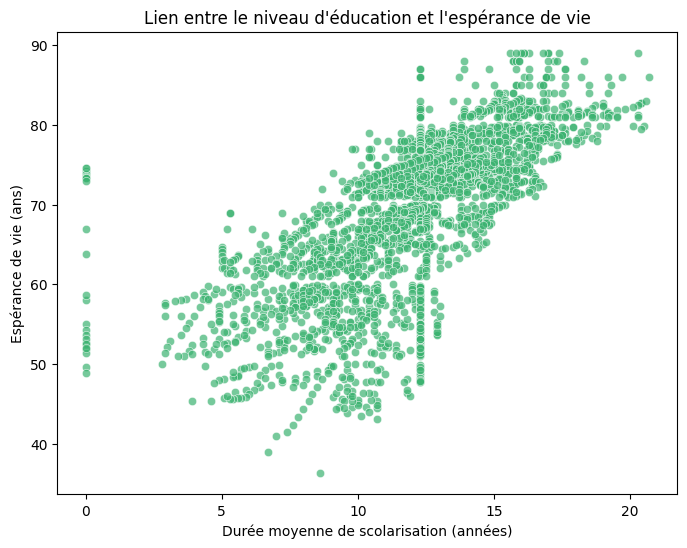

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Schooling", y="Life expectancy", alpha=0.7, color="mediumseagreen")
plt.title("Lien entre le niveau d'éducation et l'espérance de vie")
plt.xlabel("Durée moyenne de scolarisation (années)")
plt.ylabel("Espérance de vie (ans)")
plt.show()



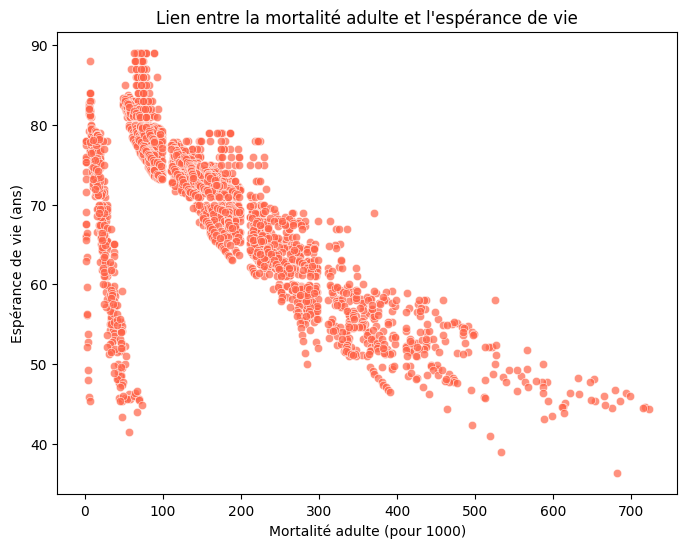

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Adult Mortality", y="Life expectancy", alpha=0.7, color="tomato")
plt.title("Lien entre la mortalité adulte et l'espérance de vie")
plt.xlabel("Mortalité adulte (pour 1000)")
plt.ylabel("Espérance de vie (ans)")
plt.show()


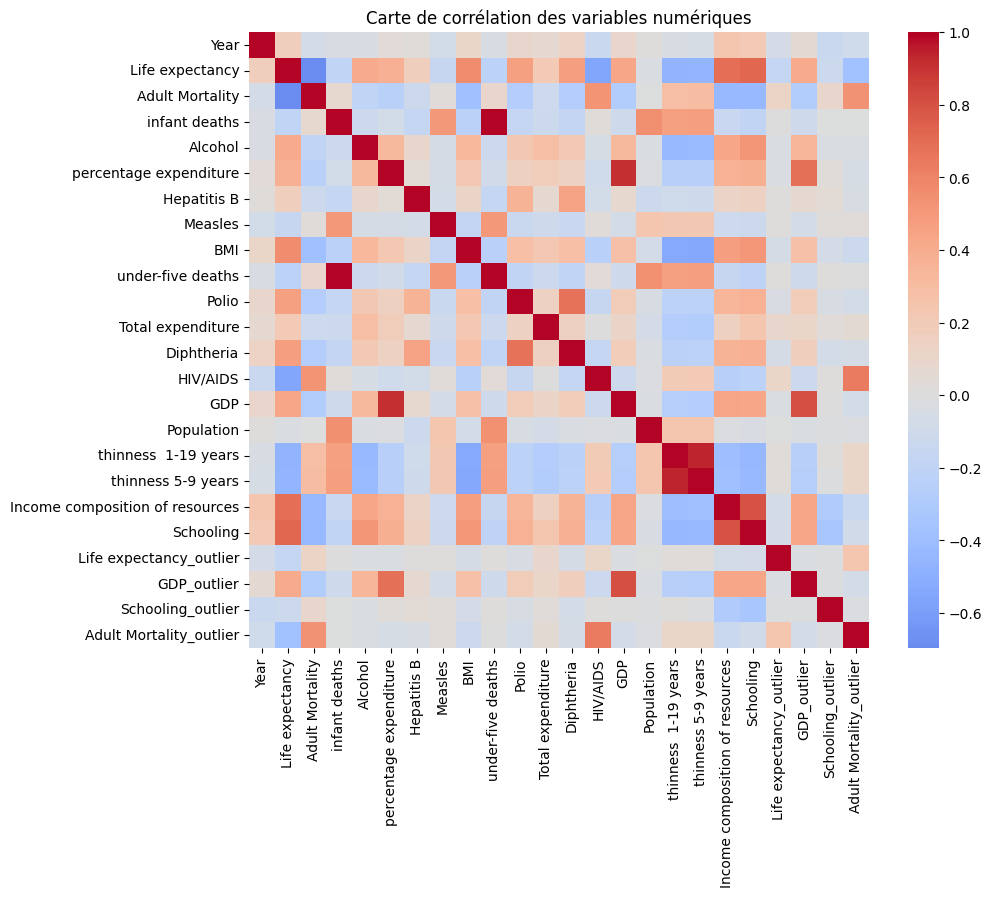

In [21]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Carte de corrélation des variables numériques")
plt.show()
